# Sparse Identification of Nonlinear Dynamics (SINDy)

The methods studied so far — **SVD/EOF** and **Dynamic Mode Decomposition (DMD)** — identify dominant spatiotemporal patterns and characterize **linear** dynamical structures in data. Many physical and geophysical systems, however, are fundamentally **nonlinear**: atmospheric convection, ocean turbulence, and biogeochemical cycling all involve nonlinear interactions that linear models cannot faithfully capture.

In this notebook, we study **SINDy** (Brunton, Proctor & Kutz, 2016), a principled framework for discovering nonlinear governing equations directly from trajectory data. The central insight exploits a key empirical observation about nature:

**Physical laws are sparse.** Despite the infinite-dimensional space of possible dynamical systems, the equations governing most natural phenomena involve only a small number of active terms from a large candidate function library.

We will derive the SINDy formulation rigorously, implement it from scratch using Sequential Thresholded Least Squares (STLS), and apply it to the **Lorenz system** — a canonical chaotic system whose three governing nonlinear ODEs we will recover from simulated trajectory data.

**Primary Reference:**
Brunton, S. L., Proctor, J. L., & Kutz, J. N. (2016). Discovering governing equations from data
by sparse identification of nonlinear dynamical systems. *Proceedings of the National Academy of
Sciences*, 113(15), 3932–3937.

## Learning Goals

By the end of this notebook, you will be able to:

1. **Formulate** the SINDy regression problem and articulate how sparsity encodes physical parsimony
2. **Construct** a polynomial candidate function library $\Theta(\mathbf{X})$ for an arbitrary state dimension
3. **Implement** the Sequential Thresholded Least Squares (STLS) algorithm from scratch
4. **Apply** SINDy to recover the full Lorenz system equations from simulated trajectory data
5. **Quantify** sensitivity to measurement noise and the sparsity threshold hyperparameter $\lambda$
6. **Connect** SINDy to open problems in geophysical model discovery, parameterization, and data assimilation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from itertools import combinations_with_replacement
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)

# Figure style
plt.rcParams.update({
    'figure.dpi': 100,
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'lines.linewidth': 1.5,
})

## Part 1: The Lorenz System

Before deriving SINDy, we generate the data we will ultimately try to rediscover from scratch.

### Background

The **Lorenz system** was derived by Edward Lorenz (1963) as a drastically simplified model of
atmospheric convection — a Galerkin truncation of the Oberbeck–Boussinesq equations to three
Fourier modes. The governing equations are:

$$\dot{x} = \sigma(y - x)$$
$$\dot{y} = x(\rho - z) - y$$
$$\dot{z} = xy - \beta z$$

where the canonical parameters are:
- $\sigma = 10$ — Prandtl number (ratio of momentum to thermal diffusivity)
- $\rho = 28$ — normalized Rayleigh number (buoyancy forcing)
- $\beta = 8/3$ — geometric factor from the domain aspect ratio

For these parameters the system is **chaotic**: trajectories exhibit sensitive dependence on initial
conditions and trace out the famous *strange attractor* without ever repeating.

Despite this complex behavior, the governing equations are remarkably simple — only **7 non-zero
terms** appear across three equations (2 in $\dot{x}$, 3 in $\dot{y}$, 2 in $\dot{z}$), all linear
or quadratic. This sparsity is precisely what SINDy will recover.

**Why is the Lorenz system a good testbed?**
- Ground truth is fully known — we can verify recovery exactly
- Nonlinear terms ($xz$ and $xy$) are essential — linear models cannot capture the attractor
- The strange attractor densely fills the phase space — rich data that constrains the regression well
- Lorenz (1963) is foundational in both chaos theory and climate science

In [2]:
# ─── Lorenz system parameters ────────────────────────────────────────────────
sigma = 10.0
rho   = 28.0
beta  = 8 / 3

def lorenz(t, state, sigma=10.0, rho=28.0, beta=8/3):
    """
    The Lorenz system of ODEs.

    Parameters
    ----------
    t : float
        Time (unused — autonomous system)
    state : array-like, shape (3,)
        Current state [x, y, z]

    Returns
    -------
    list of float
        Time derivatives [dx/dt, dy/dt, dz/dt]
    """
    x, y, z = state
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return [dxdt, dydt, dzdt]

# ─── Simulate: 20 seconds at dt = 0.01 ──────────────────────────────────────
x0          = [-8.0, 7.0, 27.0]      # initial condition near the attractor
dt          = 0.01
t_train_span = (0.0, 20.0)
t_train      = np.arange(t_train_span[0], t_train_span[1], dt)

sol_train = solve_ivp(
    lorenz, t_train_span, x0,
    t_eval=t_train, method='RK45', rtol=1e-10, atol=1e-10
)

t = sol_train.t
X = sol_train.y.T          # shape: (m, 3) — time × state variables

print(f'Training data: {len(t)} time steps,  dt = {dt} s')
print(f'State matrix X shape: {X.shape}  (time points × state dimension)')
print(f'Time span: [{t[0]:.1f}, {t[-1]:.1f}] s')
print(f'State ranges:  x ∈ [{X[:,0].min():.1f}, {X[:,0].max():.1f}],'
      f'  y ∈ [{X[:,1].min():.1f}, {X[:,1].max():.1f}],'
      f'  z ∈ [{X[:,2].min():.1f}, {X[:,2].max():.1f}]')

Training data: 2000 time steps,  dt = 0.01 s
State matrix X shape: (2000, 3)  (time points × state dimension)
Time span: [0.0, 20.0] s
State ranges:  x ∈ [-17.7, 16.6],  y ∈ [-23.7, 21.6],  z ∈ [6.4, 44.2]


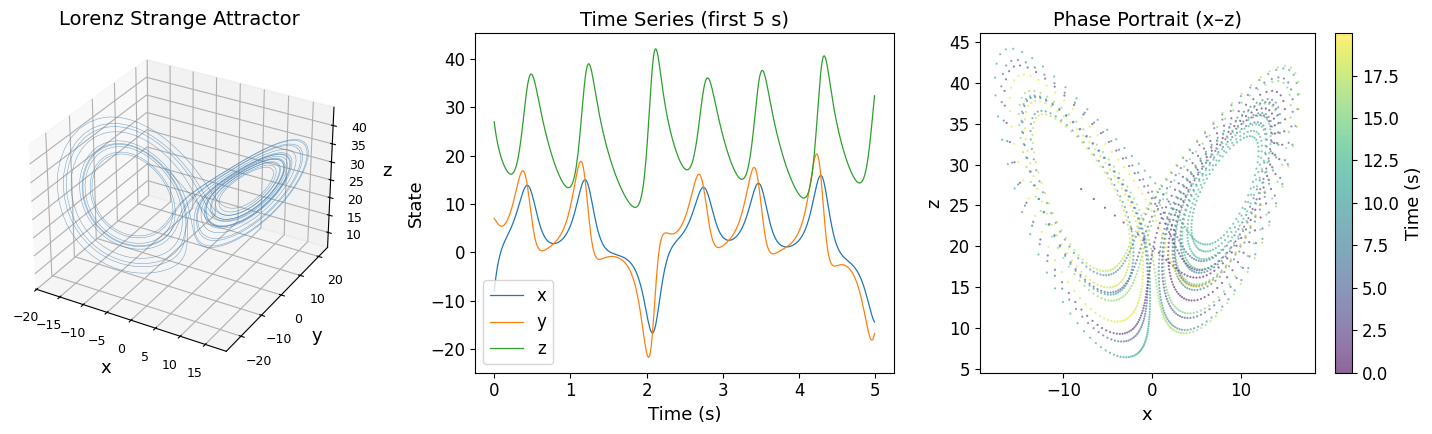

In [3]:
fig = plt.figure(figsize=(15, 4.5))

# 3D strange attractor
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot(X[:, 0], X[:, 1], X[:, 2], 'steelblue', lw=0.4, alpha=0.7)
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')
ax1.set_title('Lorenz Strange Attractor')
ax1.tick_params(labelsize=9)

# Time series (first 5 s)
ax2 = fig.add_subplot(132)
n_plot = int(5 / dt)
for j, (label, color) in enumerate(zip(['x', 'y', 'z'], ['C0', 'C1', 'C2'])):
    ax2.plot(t[:n_plot], X[:n_plot, j], color=color, lw=0.9, label=label)
ax2.set_xlabel('Time (s)'); ax2.set_ylabel('State')
ax2.set_title('Time Series (first 5 s)')
ax2.legend()

# Phase portrait x–z
ax3 = fig.add_subplot(133)
sc = ax3.scatter(X[:, 0], X[:, 2], c=t, cmap='viridis', s=0.3, alpha=0.6)
plt.colorbar(sc, ax=ax3, label='Time (s)')
ax3.set_xlabel('x'); ax3.set_ylabel('z')
ax3.set_title('Phase Portrait (x–z)')

plt.tight_layout()
plt.show()

---
## Part 2: The SINDy Framework

### Mathematical Formulation

Consider a general nonlinear autonomous dynamical system:

$$\dot{\mathbf{x}} = \mathbf{f}(\mathbf{x}), \qquad \mathbf{x} \in \mathbb{R}^n$$

where $\mathbf{f}: \mathbb{R}^n \to \mathbb{R}^n$ is an unknown (possibly nonlinear) vector field.  Given $m$ observations of the state trajectory, we organize the data into matrices:

$$\mathbf{X} = \begin{bmatrix} \mathbf{x}^\top(t_1) \\ \vdots \\ \mathbf{x}^\top(t_m) \end{bmatrix} \in \mathbb{R}^{m \times n},
\qquad
\dot{\mathbf{X}} = \begin{bmatrix} \dot{\mathbf{x}}^\top(t_1) \\ \vdots \\ \dot{\mathbf{x}}^\top(t_m) \end{bmatrix} \in \mathbb{R}^{m \times n}$$

The reason SINDy works is that $\mathbf{f}$ lies in the span of a finite, user-specified library of candidate functions $\{\theta_1(\mathbf{x}), \ldots, \theta_p(\mathbf{x})\}$. Evaluating each library function at every time snapshot gives the **library matrix**:

$$\Theta(\mathbf{X}) = \begin{bmatrix}
\theta_1(\mathbf{x}(t_1)) & \cdots & \theta_p(\mathbf{x}(t_1)) \\
\vdots & & \vdots \\
\theta_1(\mathbf{x}(t_m)) & \cdots & \theta_p(\mathbf{x}(t_m))
\end{bmatrix} \in \mathbb{R}^{m \times p}$$

The dynamics then satisfy the **linear regression problem**:

$$\dot{\mathbf{X}} = \Theta(\mathbf{X})\,\Xi$$

where $\Xi \in \mathbb{R}^{p \times n}$ is the **sparse coefficient matrix** to be identified.  Each column $\boldsymbol{\xi}_k \in \mathbb{R}^p$ gives the coefficients for the $k$-th equation: $\dot{x}_k = \Theta(\mathbf{X})\boldsymbol{\xi}_k$.

**Key insight:** Sparsity of $\Xi$ is the mathematical expression of Occam's razor — the governing equations of physical systems can be expressed compactly from a large but finite dictionary of candidate terms. Identifying the correct sparse $\Xi$ is equivalent to discovering the governing equations.

<img src="../../assets/sindy.png"></img>
### Comparison with DMD

| Aspect | DMD | SINDy |
|---|---|---|
| Model class | Linear: $\dot{\mathbf{x}} = \mathbf{A}\mathbf{x}$ | Nonlinear: $\dot{\mathbf{x}} = \Theta(\mathbf{x})\boldsymbol{\xi}$ |
| Library | Identity (state variables only) | User-specified (polynomials, trig, etc.) |
| Regression | Least squares | Sparse regression (STLS, LASSO) |
| Output | Eigenvalues + DMD modes | Sparse symbolic equations |
| Interpretability | Moderate | High — symbolic form |

---
## Part 3: Building the Candidate Library

### Choosing Candidate Functions

The library $\Theta(\mathbf{X})$ must be rich enough to contain the true dynamics but finite and
user-specified. Common choices:

| Library type | Functions | Typical use case |
|---|---|---|
| **Polynomial** | $1,\ x_i,\ x_i x_j,\ x_i x_j x_k,\ldots$ | Mechanical, fluid, climate systems |
| **Trigonometric** | $\sin(x_i),\ \cos(x_i),\ldots$ | Oscillatory and wave systems |
| **Radial basis** | $\exp(-\|\mathbf{x} - \mathbf{c}_k\|^2 / \epsilon)$ | Nonlocal features |
| **Custom** | Domain-specific terms | When prior knowledge is available |

**Polynomial library for $\mathbf{x} \in \mathbb{R}^n$, maximum degree $d$:**

The number of monomials up to degree $d$ in $n$ variables is given by the stars-and-bars formula:

$$p = \sum_{k=0}^{d} \binom{n + k - 1}{k}$$

For $n = 3$ (Lorenz: $x, y, z$) and $d = 2$:
$$p = \binom{2}{0} + \binom{3}{1} + \binom{4}{2} = 1 + 3 + 6 = 10 \text{ terms}$$

The library row at time $t_i$ is:
$$\boldsymbol{\theta}(\mathbf{x}(t_i)) =
\underbrace{\begin{bmatrix} 1 \end{bmatrix}}_{\text{deg 0}}
\underbrace{\begin{bmatrix} x & y & z \end{bmatrix}}_{\text{deg 1}}
\underbrace{\begin{bmatrix} x^2 & xy & xz & y^2 & yz & z^2 \end{bmatrix}}_{\text{deg 2}}$$

**Encoding of the Lorenz equations in $\Xi$:** With this library, the true Lorenz equations
correspond to a coefficient matrix with only 7 non-zero entries out of 30:

$$\Xi = \begin{pmatrix} 0 & 0 & 0 \\ -\sigma & \rho & 0 \\ \sigma & -1 & 0 \\ 0 & 0 & -\beta \\ 0 & 0 & 0 \\ 0 & 0 & 1 \\ 0 & -1 & 0 \\ 0 & 0 & 0 \\ 0 & 0 & 0 \\ 0 & 0 & 0 \end{pmatrix}
\leftarrow \begin{pmatrix} 1 \\ x \\ y \\ z \\ x^2 \\ xy \\ xz \\ y^2 \\ yz \\ z^2 \end{pmatrix}$$

The three columns correspond to the $\dot{x}$, $\dot{y}$, and $\dot{z}$ equations.

In [4]:
def build_polynomial_library(X, degree=2, state_names=None):
    """
    Build a polynomial candidate function library for SINDy.

    All monomials in the state variables up to the specified degree are included,
    plus a constant (bias) term.

    Parameters
    ----------
    X : ndarray, shape (m, n)
        State data — m time steps, n state variables
    degree : int
        Maximum polynomial degree
    state_names : list of str, optional
        Names for state variables. Default: ['x', 'y', 'z', 'x4', ...]

    Returns
    -------
    Theta : ndarray, shape (m, p)
        Library matrix
    names : list of str, length p
        Human-readable name for each library function
    """
    m, n = X.shape
    if state_names is None:
        defaults = ['x', 'y', 'z'] + [f'x{i}' for i in range(4, n + 1)]
        state_names = defaults[:n]

    features, names = [], []

    # Degree-0 term (constant / bias)
    features.append(np.ones((m, 1)))
    names.append('1')

    # Polynomial terms from degree 1 to max degree
    for d in range(1, degree + 1):
        for combo in combinations_with_replacement(range(n), d):
            # Compute the monomial x_{i1} * x_{i2} * ... * x_{id}
            term = np.ones(m)
            for idx in combo:
                term = term * X[:, idx]
            features.append(term.reshape(-1, 1))

            # Build human-readable name with exponent notation
            counts = {}
            for idx in combo:
                counts[idx] = counts.get(idx, 0) + 1
            parts = []
            for idx in sorted(counts):
                exp = counts[idx]
                parts.append(state_names[idx] if exp == 1
                              else f'{state_names[idx]}^{exp}')
            names.append(' '.join(parts))

    return np.hstack(features), names


# ─── Build the degree-2 polynomial library ───────────────────────────────────
Theta, lib_names = build_polynomial_library(X, degree=2)

print(f'Library matrix  Theta : {Theta.shape}  (time points × library functions)')
print(f'\nLibrary functions ({len(lib_names)} total):')
for i, name in enumerate(lib_names):
    print(f'  [{i:2d}]  {name}')

Library matrix  Theta : (2000, 10)  (time points × library functions)

Library functions (10 total):
  [ 0]  1
  [ 1]  x
  [ 2]  y
  [ 3]  z
  [ 4]  x^2
  [ 5]  x y
  [ 6]  x z
  [ 7]  y^2
  [ 8]  y z
  [ 9]  z^2


In [5]:
# Inspect the library matrix — first 5 time snapshots
print('Library matrix Theta (first 5 rows = first 5 time snapshots):\n')
header = f'{"":8s}' + '  '.join(f'{n:>8s}' for n in lib_names)
print(header)
print('-' * len(header))
for i in range(5):
    row = f't={t[i]:.3f}  ' + '  '.join(f'{Theta[i, j]:8.3f}' for j in range(len(lib_names)))
    print(row)

print(f'\nNote: the constant column is all 1s, and higher-degree monomials')
print(f'      grow rapidly for states far from the origin (Lorenz attractor')
print(f'      reaches |z| ~ 40, so z^2 ~ 1600).')

Library matrix Theta (first 5 rows = first 5 time snapshots):

               1         x         y         z       x^2       x y       x z       y^2       y z       z^2
----------------------------------------------------------------------------------------------------------
t=0.000     1.000    -8.000     7.000    27.000    64.000   -56.000  -216.000    49.000   189.000   729.000
t=0.010     1.000    -6.581     6.815    25.793    43.310   -44.848  -169.745    46.441   175.774   665.287
t=0.020     1.000    -5.317     6.585    24.722    28.272   -35.015  -131.449    43.368   162.803   611.166
t=0.030     1.000    -4.196     6.343    23.768    17.608   -26.617   -99.737    40.234   150.765   564.941
t=0.040     1.000    -3.205     6.109    22.916    10.270   -19.578   -73.439    37.324   140.004   525.159

Note: the constant column is all 1s, and higher-degree monomials
      grow rapidly for states far from the origin (Lorenz attractor
      reaches |z| ~ 40, so z^2 ~ 1600).


---
## Part 4: Computing Time Derivatives

SINDy requires both the state trajectory $\mathbf{X}$ and the time derivatives $\dot{\mathbf{X}}$.
In practice, derivatives must be estimated from measurements — a numerically sensitive step.

### Derivative Estimation Strategies

| Method | Order | Noise sensitivity | Notes |
|---|---|---|---|
| Forward/backward differences | $O(\Delta t)$ | High | Boundary only |
| Central differences | $O(\Delta t^2)$ | High | Interior points |
| High-order finite differences | $O(\Delta t^4)$ | Moderate | `np.gradient` |
| Total variation regularization (TVR) | — | Low | Convex optimization |
| Weak/integral formulation (WSINDy) | — | Very low | Test function approach |

For noisy data, finite differences amplify high-frequency noise because differentiation is an
ill-posed operation. The noise level in the derivative scales as $O(\varepsilon / \Delta t)$
where $\varepsilon$ is the measurement noise amplitude — motivating either regularized
differentiation or the weak formulation.

**For this notebook** we explore two scenarios:
1. **Exact derivatives (oracle):** Computed directly from the Lorenz ODE. Verifies algebraic
   correctness of SINDy independent of numerical differentiation.
2. **Numerical derivatives:** Estimated via `np.gradient` (4th-order central differences at
   interior points). Mimics the realistic setting with only state measurements available.

Numerical vs. exact derivative accuracy:
  dx/dt:  max |error| = 8.10226,  mean |error| = 0.093174
  dy/dt:  max |error| = 9.24263,  mean |error| = 0.201252
  dz/dt:  max |error| = 7.31490,  mean |error| = 0.194850


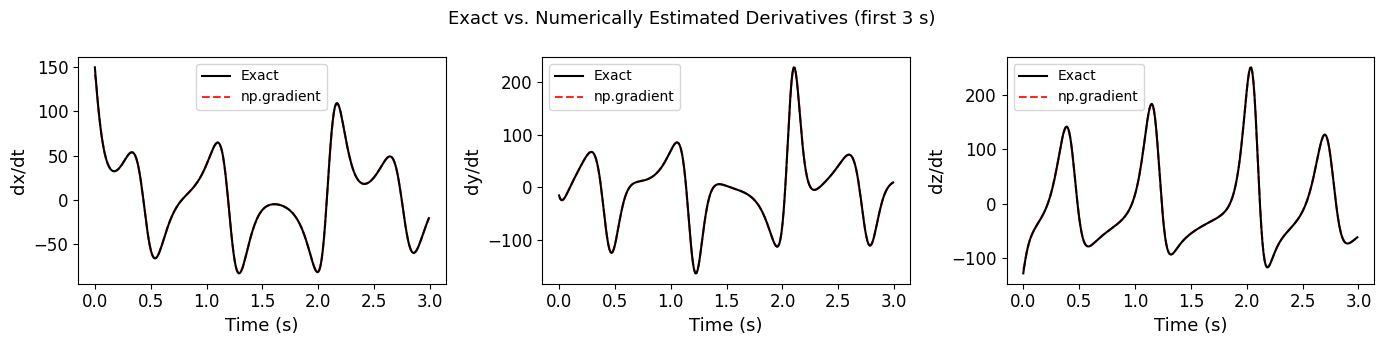

In [6]:
def compute_exact_derivatives(t_arr, X_arr, sigma=10.0, rho=28.0, beta=8/3):
    """
    Compute exact time derivatives using the Lorenz ODE (oracle experiment).

    This represents the ideal case: noise-free, analytically exact derivatives.
    Used to verify that SINDy correctly identifies the equations when the
    bottleneck of numerical differentiation is removed.
    """
    dX = np.zeros_like(X_arr)
    for i in range(len(t_arr)):
        dX[i] = lorenz(t_arr[i], X_arr[i], sigma, rho, beta)
    return dX


def compute_numerical_derivatives(X_arr, dt_val):
    """
    Estimate time derivatives using numpy.gradient.

    Uses second-order central differences for interior points and
    first-order one-sided differences at the boundaries.
    For uniform sampling with step dt_val.
    """
    return np.gradient(X_arr, dt_val, axis=0)


# ─── Compute both ─────────────────────────────────────────────────────────────
dX_exact     = compute_exact_derivatives(t, X)
dX_numerical = compute_numerical_derivatives(X, dt)

# Assess numerical accuracy
abs_err = np.abs(dX_exact - dX_numerical)
print('Numerical vs. exact derivative accuracy:')
for j, label in enumerate(['dx/dt', 'dy/dt', 'dz/dt']):
    print(f'  {label}:  max |error| = {abs_err[:, j].max():.5f},  '
          f'mean |error| = {abs_err[:, j].mean():.6f}')

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
n_show = int(3 / dt)  # first 3 seconds
for j, (ax, label) in enumerate(zip(axes, ['dx/dt', 'dy/dt', 'dz/dt'])):
    ax.plot(t[:n_show], dX_exact[:n_show, j], 'k-', lw=1.5, label='Exact', zorder=3)
    ax.plot(t[:n_show], dX_numerical[:n_show, j], 'r--', lw=1.5,
            label='np.gradient', alpha=0.85)
    ax.set_xlabel('Time (s)'); ax.set_ylabel(label)
    ax.legend(fontsize=10)
plt.suptitle('Exact vs. Numerically Estimated Derivatives (first 3 s)', fontsize=13)
plt.tight_layout()
plt.show()

---
## Part 5: Sparse Regression via STLS

### Sequential Thresholded Least Squares

The regression problem $\dot{\mathbf{X}} \approx \Theta(\mathbf{X})\Xi$ is underdetermined
when the library is large ($p > n$). Sparsity must be imposed algorithmically.

**Why not LASSO?**
$\ell_1$-regularized regression (LASSO) is a popular convex relaxation for sparse problems:
$\min_{\Xi} \|\dot{\mathbf{X}} - \Theta\Xi\|_F^2 + \lambda\|\Xi\|_1$.
However, LASSO produces **biased** coefficient estimates (shrinkage toward zero) and can
struggle with the highly correlated columns typical of polynomial libraries ($x$ and $x^2$
are correlated for bounded state trajectories). The estimated coefficients are harder to
interpret physically.

**STLS** (Brunton et al., 2016) combines hard thresholding with unbiased refitting:

---
**Algorithm: Sequential Thresholded Least Squares (STLS)**

*Input:* Library $\Theta \in \mathbb{R}^{m \times p}$,  derivatives $\dot{\mathbf{X}} \in \mathbb{R}^{m \times n}$,  threshold $\lambda > 0$

1. **Initialize:** $\Xi \leftarrow \Theta^\dagger \dot{\mathbf{X}}$ (unconstrained least squares)
2. **Repeat** until convergence:
   - **Threshold:** for all $(i, j)$, if $|\Xi_{ij}| < \lambda$ then $\Xi_{ij} \leftarrow 0$
   - **Refit:** for each column $j$, let $\mathcal{A}_j = \{i : |\Xi_{ij}| \geq \lambda\}$ (active set),
     then $\boldsymbol{\xi}_{\mathcal{A}_j, j} \leftarrow (\Theta_{:, \mathcal{A}_j})^\dagger \dot{\mathbf{x}}_j$

*Output:* Sparse coefficient matrix $\Xi$

---

**Properties:**
- Each thresholding step removes spurious terms
- Refitting on the active set gives **unbiased** estimates of the retained coefficients
- Typically converges in 5–10 iterations
- The active set can only shrink (monotone), ensuring convergence

**Threshold selection:** Too small $\lambda$ → too many terms (overfit). Too large $\lambda$
→ correct terms removed (underfit). Selection strategies include cross-validation,
information criteria (AIC/BIC), or the sparsity–accuracy Pareto front (explored below).

In [7]:
def stls(Theta, dX, threshold=0.05, max_iter=20, verbose=False):
    """
    Sequential Thresholded Least Squares (STLS) for sparse regression.

    Solves:  min_{Xi} ||dX - Theta @ Xi||_F   subject to Xi being sparse.

    Parameters
    ----------
    Theta : ndarray, shape (m, p)
        Library (feature) matrix
    dX : ndarray, shape (m, n)
        Time derivative matrix
    threshold : float
        Sparsity threshold lambda — coefficients with |Xi_ij| < threshold
        are set to zero at each iteration
    max_iter : int
        Maximum number of thresholding–refit iterations
    verbose : bool
        Print iteration diagnostics

    Returns
    -------
    Xi : ndarray, shape (p, n)
        Sparse coefficient matrix
    active_counts : list of int
        Number of active (non-zero) terms per iteration (for convergence diagnostics)
    """
    # Step 1: Unconstrained least-squares initialization (pseudoinverse)
    Xi = np.linalg.lstsq(Theta, dX, rcond=None)[0]   # shape (p, n)
    active_counts = [int(np.sum(np.abs(Xi) > 1e-12))]

    for k in range(max_iter):
        Xi_prev = Xi.copy()

        # Step 2a: Hard threshold — zero out small coefficients
        small = np.abs(Xi) < threshold
        Xi[small] = 0.0

        # Step 2b: Refit on active set for each target equation
        for j in range(dX.shape[1]):
            active = ~small[:, j]        # boolean mask of active library terms
            if active.sum() == 0:
                continue                  # degenerate: all terms zeroed
            Xi[active, j] = np.linalg.lstsq(
                Theta[:, active], dX[:, j], rcond=None
            )[0]

        n_active = int(np.sum(np.abs(Xi) > 1e-12))
        active_counts.append(n_active)

        if verbose:
            print(f'  Iteration {k+1:2d}: {n_active} active terms')

        # Convergence: active set unchanged between iterations
        if np.max(np.abs(Xi - Xi_prev)) < 1e-12:
            if verbose:
                print(f'  Converged at iteration {k+1}.')
            break

    return Xi, active_counts


print('STLS implementation ready.')

# Quick sanity check on a random problem
m_test, p_test, n_test = 200, 10, 3
A_test = np.random.randn(m_test, p_test)
xi_true_test = np.zeros((p_test, n_test))
xi_true_test[[0, 3, 7], :] = np.random.randn(3, n_test)  # sparse truth
b_test = A_test @ xi_true_test + 0.01 * np.random.randn(m_test, n_test)
xi_hat, _ = stls(A_test, b_test, threshold=0.3)
print(f'Sanity check recovery error: {np.linalg.norm(xi_hat - xi_true_test):.4f}')

STLS implementation ready.
Sanity check recovery error: 0.2588


---
## Part 6: Applying SINDy to the Lorenz System

We now run the full SINDy pipeline. The three steps are:
1. Build the library matrix $\Theta(\mathbf{X})$ from state data
2. Estimate time derivatives $\dot{\mathbf{X}}$
3. Solve the sparse regression $\dot{\mathbf{X}} \approx \Theta(\mathbf{X})\Xi$ via STLS

We begin with **exact derivatives** (oracle) to verify the method algebraically, then
switch to numerical derivatives in later sections.

In [8]:
# ─── Oracle experiment: exact derivatives ────────────────────────────────────
lambda_threshold = 0.2    # sparsity threshold lambda

print(f'Running STLS  (threshold lambda = {lambda_threshold})  ...')
print(f'Library: {Theta.shape[1]} candidate functions, {X.shape[0]} time snapshots\n')

Xi_exact, active_hist = stls(
    Theta, dX_exact,
    threshold=lambda_threshold,
    verbose=True
)

n_zero   = np.sum(np.abs(Xi_exact) < 1e-10)
n_active = Xi_exact.size - n_zero
print(f'\nResult: {n_active} non-zero coefficients out of {Xi_exact.size}  '
      f'({100 * n_zero / Xi_exact.size:.0f}% sparse)')

Running STLS  (threshold lambda = 0.2)  ...
Library: 10 candidate functions, 2000 time snapshots

  Iteration  1: 7 active terms
  Converged at iteration 1.

Result: 7 non-zero coefficients out of 30  (77% sparse)


In [9]:
def print_sindy_equations(Xi, lib_names, state_labels=None, tol=1e-6):
    """
    Print SINDy-identified governing equations in readable symbolic form.

    Parameters
    ----------
    Xi : ndarray, shape (p, n)
        Sparse coefficient matrix from STLS
    lib_names : list of str
        Library function names
    state_labels : list of str, optional
        Labels for the derivative of each state variable
    tol : float
        Coefficients below this threshold are treated as zero
    """
    n_targets = Xi.shape[1]
    if state_labels is None:
        state_labels = ['dx/dt', 'dy/dt', 'dz/dt'][:n_targets]

    print('Discovered Governing Equations')
    print('=' * 60)
    for j, label in enumerate(state_labels):
        terms = []
        for i, name in enumerate(lib_names):
            c = Xi[i, j]
            if abs(c) > tol:
                term = (f'{c:+.4f}' if name == '1'
                        else f'{c:+.4f} {name}')
                terms.append(term)
        eq = '  '.join(terms) if terms else '0'
        print(f'  {label} = {eq}')
    print()


print('=== SINDy identified equations (exact derivatives) ===\n')
print_sindy_equations(Xi_exact, lib_names)

print('=== True Lorenz equations ===\n')
print(f'  dx/dt = {-sigma:+.4f} x  {+sigma:+.4f} y')
print(f'  dy/dt = {+rho:+.4f} x  {-1.0:+.4f} y  {-1.0:+.4f} x z')
print(f'  dz/dt = {-beta:+.4f} z  {+1.0:+.4f} x y')

=== SINDy identified equations (exact derivatives) ===

Discovered Governing Equations
  dx/dt = -10.0000 x  +10.0000 y
  dy/dt = +28.0000 x  -1.0000 y  -1.0000 x z
  dz/dt = -2.6667 z  +1.0000 x y

=== True Lorenz equations ===

  dx/dt = -10.0000 x  +10.0000 y
  dy/dt = +28.0000 x  -1.0000 y  -1.0000 x z
  dz/dt = -2.6667 z  +1.0000 x y


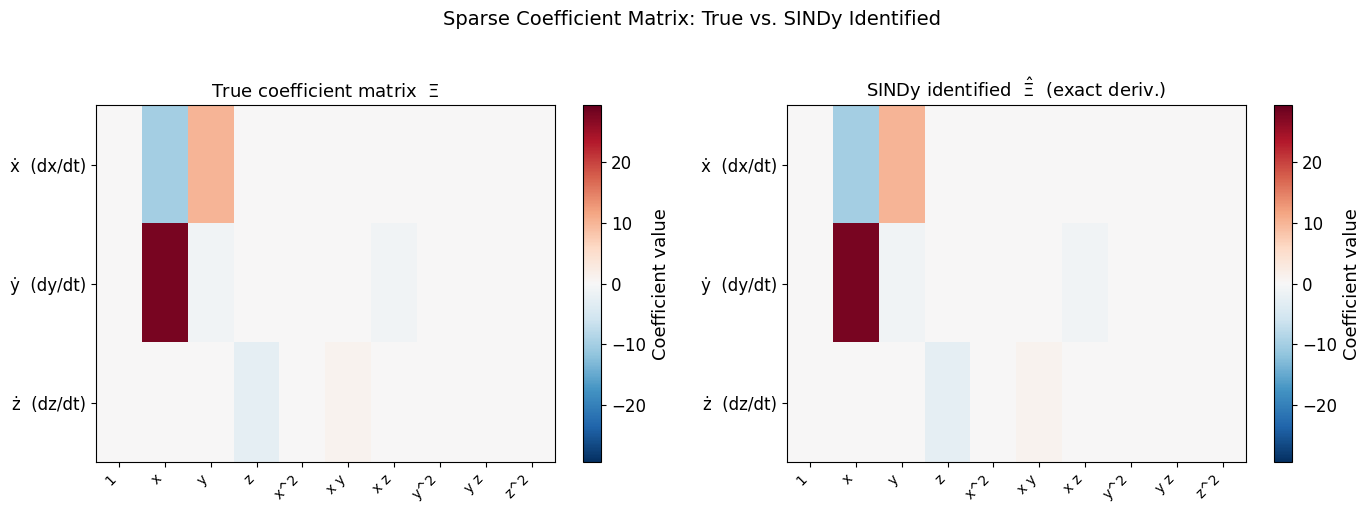

Relative Frobenius error  ||Xi - Xi_true|| / ||Xi_true|| = 1.75e-15


In [10]:
# ─── Construct the true coefficient matrix ────────────────────────────────────
# Library index map: 0=1, 1=x, 2=y, 3=z, 4=x^2, 5=xy, 6=xz, 7=y^2, 8=yz, 9=z^2
Xi_true = np.zeros((len(lib_names), 3))
#  dx/dt = -sigma*x + sigma*y
Xi_true[1, 0] = -sigma        # x
Xi_true[2, 0] = +sigma        # y
#  dy/dt = rho*x - y - xz
Xi_true[1, 1] = +rho          # x
Xi_true[2, 1] = -1.0          # y
Xi_true[6, 1] = -1.0          # xz
#  dz/dt = -beta*z + xy
Xi_true[3, 2] = -beta         # z
Xi_true[5, 2] = +1.0          # xy

# ─── Coefficient heatmap: true vs. identified ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vmax = max(abs(Xi_true).max(), abs(Xi_exact).max()) * 1.05

for ax, Xi_plot, title in zip(
        axes,
        [Xi_true, Xi_exact],
        ['True coefficient matrix  $\\Xi$',
         'SINDy identified  $\\hat{\\Xi}$  (exact deriv.)']):
    im = ax.imshow(Xi_plot.T, aspect='auto', cmap='RdBu_r',
                   vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(len(lib_names)))
    ax.set_xticklabels(lib_names, rotation=45, ha='right', fontsize=10)
    ax.set_yticks(range(3))
    ax.set_yticklabels(['\u1e8b  (dx/dt)', '\u1e8f  (dy/dt)', '\u017c  (dz/dt)'],
                       fontsize=12)
    ax.set_title(title, fontsize=13)
    plt.colorbar(im, ax=ax, label='Coefficient value')

plt.suptitle('Sparse Coefficient Matrix: True vs. SINDy Identified', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

err = np.linalg.norm(Xi_exact - Xi_true) / np.linalg.norm(Xi_true)
print(f'Relative error  ||Xi - Xi_true|| / ||Xi_true|| = {err:.2e}')

---
## Part 7: Validation — Simulating the Identified Model

A necessary (but not sufficient) test of the identified equations is to simulate the discovered
system forward in time and compare with the true trajectory. We use a new initial condition
not present in the training data.

**Caution:** Because the Lorenz system is chaotic, even two identical models initialized at
slightly different states will diverge exponentially (Lyapunov exponent $\approx 0.9$ bits/s
for canonical parameters). Therefore, good short-time prediction but eventual divergence is
physically expected — even when the model is correct. We assess:
1. Short-time prediction accuracy (deterministic regime)
2. Long-time attractor statistics (ergodic regime)

In [11]:
def ode_sindy(t_pt, state, Xi_coef):
    """
    ODE right-hand side defined by SINDy-identified coefficients.

    Evaluates the discovered equations at a single state point.
    """
    s = np.array(state).reshape(1, 3)
    Theta_s, _ = build_polynomial_library(s, degree=2, state_names=['x', 'y', 'z'])
    return (Theta_s @ Xi_coef).flatten()


# Validation: new initial condition not in training data
x0_val       = np.array([-8.1, 7.2, 27.5])
t_val_span   = (0.0, 15.0)
t_val        = np.arange(*t_val_span, dt)

# True Lorenz trajectory
sol_true_val = solve_ivp(
    lorenz, t_val_span, x0_val,
    t_eval=t_val, method='RK45', rtol=1e-10, atol=1e-10
)

# SINDy-identified trajectory
sol_sindy_val = solve_ivp(
    ode_sindy, t_val_span, x0_val,
    args=(Xi_exact,),
    t_eval=t_val, method='RK45', rtol=1e-10, atol=1e-10
)

X_true_val  = sol_true_val.y.T
X_sindy_val = sol_sindy_val.y.T

print(f'Validation trajectories: {len(t_val)} steps over t in [0, 15] s')
print(f'True shape: {X_true_val.shape},  SINDy shape: {X_sindy_val.shape}')

Validation trajectories: 1500 steps over t in [0, 15] s
True shape: (1500, 3),  SINDy shape: (1500, 3)


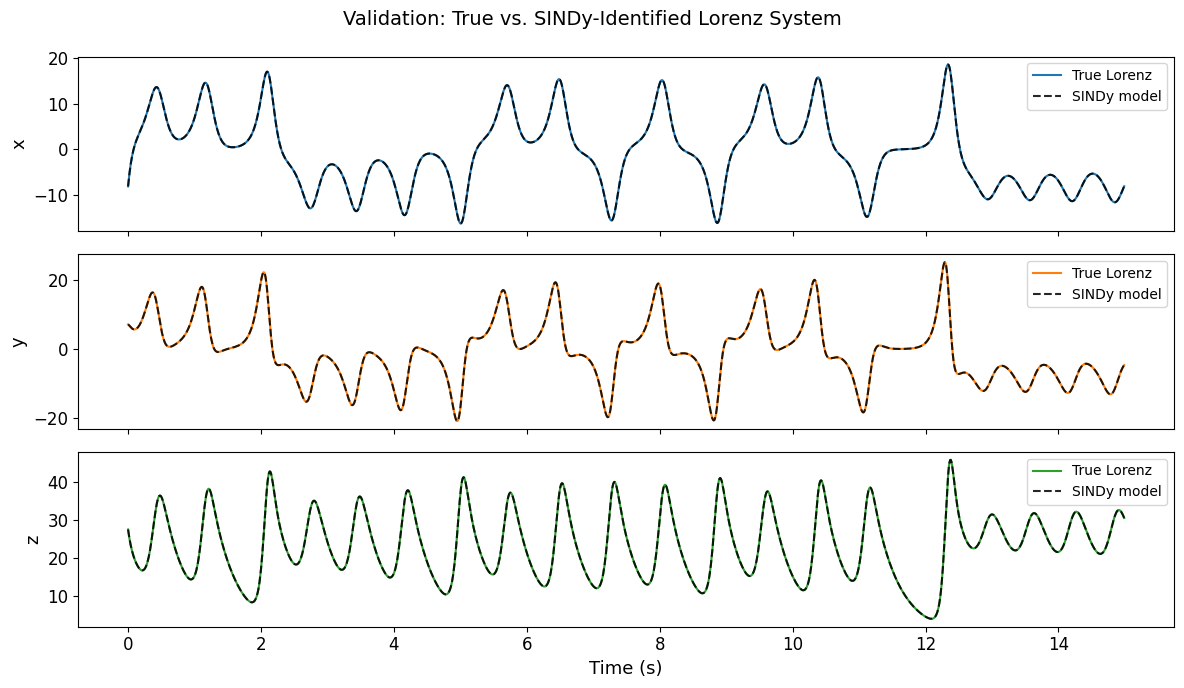

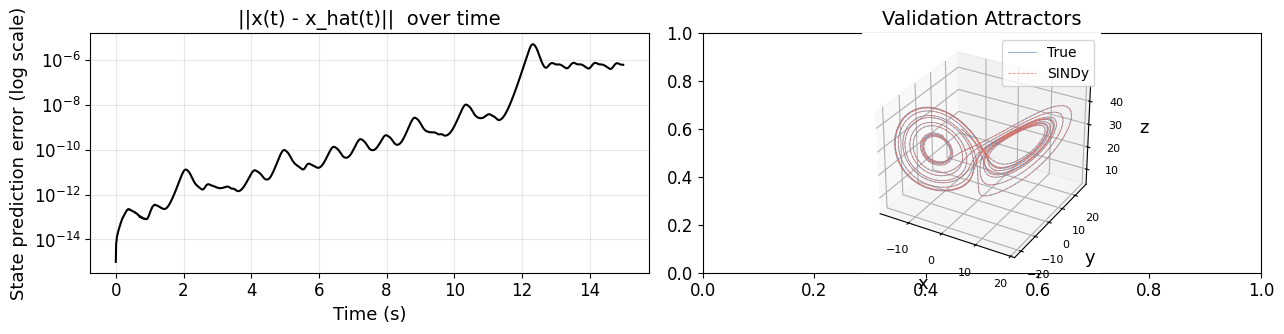

In [12]:
# ─── Time series comparison ───────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
for j, (ax, label, color) in enumerate(zip(axes, ['x', 'y', 'z'], ['C0', 'C1', 'C2'])):
    ax.plot(t_val, X_true_val[:, j], color=color, lw=1.5, label='True Lorenz')
    ax.plot(t_val, X_sindy_val[:, j], 'k--', lw=1.5, label='SINDy model', alpha=0.85)
    ax.set_ylabel(label, fontsize=13)
    ax.legend(loc='upper right', fontsize=10)
axes[-1].set_xlabel('Time (s)')
plt.suptitle('Validation: True vs. SINDy-Identified Lorenz System', fontsize=14)
plt.tight_layout()
plt.show()

# ─── Prediction error ─────────────────────────────────────────────────────────
error = np.sqrt(np.sum((X_true_val - X_sindy_val) ** 2, axis=1))

fig, axes2 = plt.subplots(1, 2, figsize=(13, 3.5))

# Error over time
axes2[0].semilogy(t_val, error + 1e-15, 'k', lw=1.5)
axes2[0].set_xlabel('Time (s)')
axes2[0].set_ylabel('State prediction error (log scale)')
axes2[0].set_title('||x(t) - x_hat(t)||  over time')
axes2[0].grid(True, which='both', alpha=0.3)

# 3D attractor comparison
ax3d = fig.add_subplot(122, projection='3d')
ax3d.plot(X_true_val[:, 0], X_true_val[:, 1], X_true_val[:, 2],
          'steelblue', lw=0.6, alpha=0.7, label='True')
ax3d.plot(X_sindy_val[:, 0], X_sindy_val[:, 1], X_sindy_val[:, 2],
          'tomato', lw=0.6, alpha=0.7, label='SINDy', ls='--')
ax3d.set_xlabel('x'); ax3d.set_ylabel('y'); ax3d.set_zlabel('z')
ax3d.set_title('Validation Attractors')
ax3d.legend(fontsize=10)
ax3d.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

---
## Part 8: Robustness and Sensitivity Analysis

### Effect of Measurement Noise

Real observational data is corrupted by measurement noise. Two effects compound:

1. **Noisy library:** $\Theta(\mathbf{X} + \varepsilon)$ — library features computed from
   noisy states activate incorrectly (e.g., high-degree monomials are amplified)

2. **Noisy derivative estimates:** Numerical differentiation of noisy signals amplifies
   noise by $O(1/\Delta t)$, severely corrupting $\dot{\mathbf{X}}$

We add i.i.d. Gaussian noise scaled to a fraction of each signal's standard deviation.

### Threshold Hyperparameter Selection

The threshold $\lambda$ controls the fundamental **sparsity–accuracy tradeoff**:
- **Too small:** The initial least-squares solution is retained almost unchanged → many
  spurious small coefficients survive → overfit
- **Optimal:** Active set converges to the true support → clean recovery
- **Too large:** Correct terms are pruned → underfitted, structurally wrong model

A **Pareto front** of model complexity (number of active terms) vs. reconstruction
accuracy across $\lambda$ values reveals the optimal operating point.

    Noise level    Coef. error (rel.)  Active terms
-------------------------------------------------------
        0.10 %               0.00624             7
        0.50 %               0.00690             7
        1.00 %               0.00372             7
        5.00 %               0.03422             8
       10.00 %               0.09650             9
       50.00 %               0.93275            14


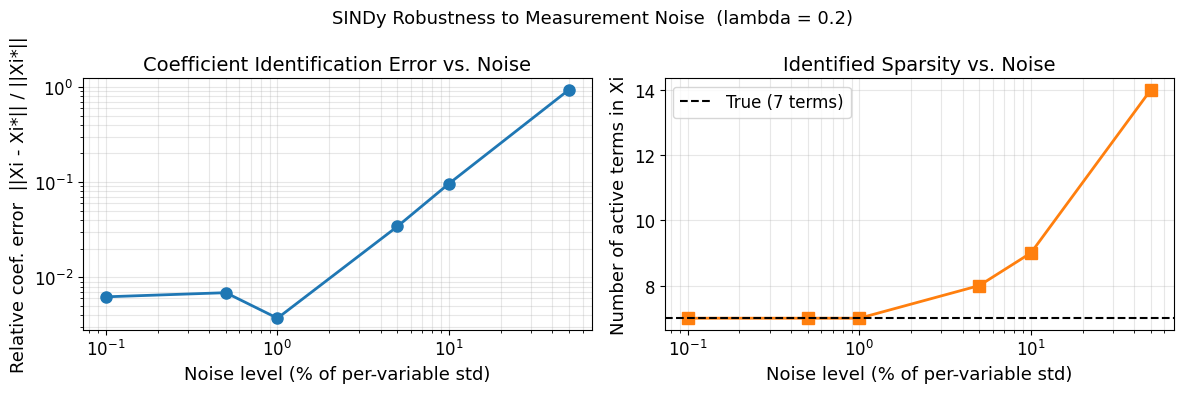

In [13]:
# ─── Noise robustness experiment ─────────────────────────────────────────────
noise_fracs = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5]
X_signal_std = np.std(X, axis=0, keepdims=True)   # per-variable signal amplitude

coef_rel_errors = []
n_active_found  = []

print(f'{"Noise level":>15s}  {"Coef. error (rel.)": >20s}  {"Active terms":>12s}')
print('-' * 55)

for nf in noise_fracs:
    # Add i.i.d. Gaussian noise proportional to each variable's std
    X_noisy  = X + nf * X_signal_std * np.random.randn(*X.shape)

    # Estimate derivatives from noisy measurements
    dX_noisy = compute_numerical_derivatives(X_noisy, dt)

    # Build library from noisy state data
    Theta_noisy, _ = build_polynomial_library(X_noisy, degree=2)

    # Run STLS
    Xi_noisy, _ = stls(Theta_noisy, dX_noisy, threshold=lambda_threshold)

    rel_err  = np.linalg.norm(Xi_noisy - Xi_true) / np.linalg.norm(Xi_true)
    n_active = int(np.sum(np.abs(Xi_noisy) > 1e-10))
    coef_rel_errors.append(rel_err)
    n_active_found.append(n_active)

    print(f'  {nf*100:>10.2f} %  {rel_err:>20.5f}  {n_active:>12d}')

# ─── Plot noise robustness ────────────────────────────────────────────────────
noise_pct = np.array(noise_fracs) * 100
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.loglog(noise_pct, coef_rel_errors, 'o-', color='C0', lw=2, ms=8)
ax1.set_xlabel('Noise level (% of per-variable std)')
ax1.set_ylabel('Relative coef. error  ||Xi - Xi*|| / ||Xi*||')
ax1.set_title('Coefficient Identification Error vs. Noise')
ax1.grid(True, which='both', alpha=0.3)

ax2.semilogx(noise_pct, n_active_found, 's-', color='C1', lw=2, ms=8)
ax2.axhline(7, color='k', ls='--', lw=1.5, label='True (7 terms)')
ax2.set_xlabel('Noise level (% of per-variable std)')
ax2.set_ylabel('Number of active terms in Xi')
ax2.set_title('Identified Sparsity vs. Noise')
ax2.legend()
ax2.grid(True, which='both', alpha=0.3)

plt.suptitle(f'SINDy Robustness to Measurement Noise  (lambda = {lambda_threshold})',
             fontsize=13)
plt.tight_layout()
plt.show()

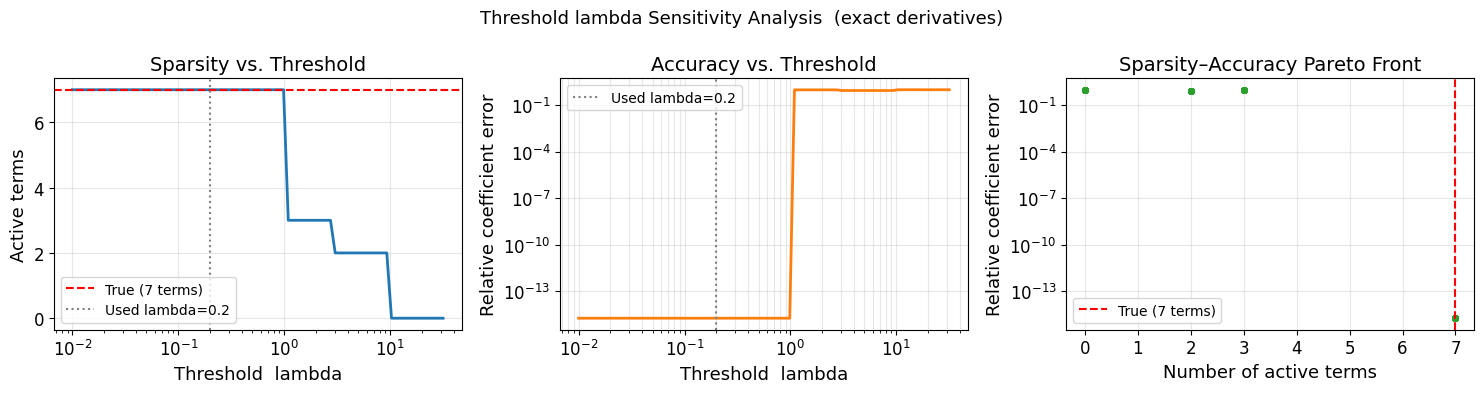

Correct sparsity (7 terms) recovered for lambda in [0.010, 0.986]


In [14]:
# ─── Threshold sensitivity: Pareto analysis ───────────────────────────────────
# Use exact derivatives to isolate the effect of lambda
lambdas      = np.logspace(-2, 1.5, 80)
n_terms_list = []
err_list     = []

for lam in lambdas:
    Xi_lam, _ = stls(Theta, dX_exact, threshold=lam)
    n_terms_list.append(int(np.sum(np.abs(Xi_lam) > 1e-10)))
    err_list.append(
        np.linalg.norm(Xi_lam - Xi_true) / np.linalg.norm(Xi_true)
    )

n_true_terms = int(np.sum(np.abs(Xi_true) > 1e-10))
err_arr = np.array(err_list) + 1e-16    # avoid log(0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Sparsity vs. lambda
axes[0].semilogx(lambdas, n_terms_list, lw=2, color='C0')
axes[0].axhline(n_true_terms, color='r', ls='--',
                label=f'True ({n_true_terms} terms)')
axes[0].axvline(lambda_threshold, color='gray', ls=':',
                label=f'Used lambda={lambda_threshold}')
axes[0].set_xlabel('Threshold  lambda'); axes[0].set_ylabel('Active terms')
axes[0].set_title('Sparsity vs. Threshold')
axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3)

# Accuracy vs. lambda
axes[1].loglog(lambdas, err_arr, lw=2, color='C1')
axes[1].axvline(lambda_threshold, color='gray', ls=':',
                label=f'Used lambda={lambda_threshold}')
axes[1].set_xlabel('Threshold  lambda')
axes[1].set_ylabel('Relative coefficient error')
axes[1].set_title('Accuracy vs. Threshold')
axes[1].legend(fontsize=10); axes[1].grid(True, which='both', alpha=0.3)

# Pareto front: #terms vs. error
axes[2].semilogy(n_terms_list, err_arr, 'o', color='C2', ms=4, alpha=0.7)
axes[2].axvline(n_true_terms, color='r', ls='--',
                label=f'True ({n_true_terms} terms)')
axes[2].set_xlabel('Number of active terms')
axes[2].set_ylabel('Relative coefficient error')
axes[2].set_title('Sparsity–Accuracy Pareto Front')
axes[2].legend(fontsize=10); axes[2].grid(True, which='both', alpha=0.3)

plt.suptitle('Threshold lambda Sensitivity Analysis  (exact derivatives)',
             fontsize=13)
plt.tight_layout()
plt.show()

# Show the range of lambda values that recover the correct sparsity
correct_sparsity = np.array(n_terms_list) == n_true_terms
if correct_sparsity.any():
    print(f'Correct sparsity ({n_true_terms} terms) recovered for '
          f'lambda in [{lambdas[correct_sparsity].min():.3f}, '
          f'{lambdas[correct_sparsity].max():.3f}]')

---
## Part 9: Extensions and Connections to Earth Science

### Major Extensions of SINDy

Since the original 2016 paper, many methodological extensions have appeared:

| Extension | Key idea | Reference |
|---|---|---|
| **SINDy-C** | Include exogenous control inputs $\mathbf{u}(t)$ in the library | Brunton et al. (2016) |
| **SINDy-PI** | Implicit formulation for rational/algebraic ODEs | Messenger & Bortz (2021) |
| **WSINDy** | Weak formulation via test functions — robust to high noise | Messenger & Bortz (2021) |
| **Ensemble SINDy** | Bootstrap resampling for uncertainty quantification of identified terms | Fasel et al. (2022) |
| **SINDy + autoencoders** | Learn latent coordinates in which dynamics are sparse | Champion et al. (2019) |
| **PDE-FIND** | Sparse regression for partial differential equations | Rudy et al. (2017) |
| **SINDy-BVP** | Identify steady-state and boundary value problems | |
| **SR3** | Sparse relaxed regularized regression — improved optimization landscape | Zheng et al. (2019) |

### Connections to Geophysical Fluid Dynamics

SINDy addresses several open problems in Earth system science:

**Parameterization of sub-grid-scale processes:**
In atmospheric and ocean models, convection, turbulent mixing, and gravity wave drag must
be parameterized because their scales ($\sim$100 m) are unresolvable in global models
($\sim$10–100 km). Traditional parameterizations are empirical closures tuned against
observations. SINDy offers a systematic route to discovering data-driven parameterizations
that are *interpretable* and *physically constrained* — unlike black-box neural networks.

**Low-dimensional models of climate variability:**
Applied to the time series of EOF coefficients (the temporal evolution of dominant
spatial patterns), SINDy can discover the nonlinear ODEs governing coupled climate modes
such as ENSO, the AMO, or the annular modes. This connects directly to the previous
notebooks on EOF analysis and DMD.

**Turbulence and energy cascades:**
In turbulent flows, POD/EOF coefficients evolve according to a Galerkin-projected
Navier–Stokes system — a high-dimensional quadratic ODE (Noack et al., 2003). SINDy
can identify low-rank approximations to this system purely from flow measurements,
without access to the Navier–Stokes equations.

**Biogeochemical cycles:**
Ocean biogeochemical models involve nonlinear reaction kinetics for nutrient uptake,
phytoplankton growth, and carbon export. SINDy can identify functional forms of these
processes from observational time series — an alternative to mechanistic model fitting
that does not require specifying the functional form in advance.

**PDE discovery from field data:**
PDE-FIND (Rudy et al., 2017) extends SINDy to discover partial differential equations
from spatiotemporal field data. Applied to satellite altimetry or ocean reanalysis products,
this could recover eddy-mean flow interactions or Rossby wave dispersion relations
data-analytically.

### Open Challenges

- **Non-polynomial dynamics:** Many geophysical processes involve saturation functions,
  conditional expressions, or threshold behavior not captured by polynomial libraries.
  Library design remains problem-specific and requires domain knowledge.

- **Noisy, irregular, gappy observations:** Real geophysical data have missing values,
  irregular temporal sampling, and complex structured noise — all of which degrade
  derivative estimation. WSINDy and derivative-free formulations are active research areas.

- **Identifiability and uniqueness:** When does the sparse solution uniquely identify
  the true equations? This depends on the restricted isometry property (RIP) of the library
  matrix, which is not guaranteed for nonlinear, correlated libraries.

- **Incorporating physical constraints:** Energy conservation, Galilean invariance,
  symmetry groups, and thermodynamic consistency are hard to enforce in a pure
  regression framework. Structure-preserving variants are an active research area.

---
## Summary

**SINDy in one sentence:** Given state trajectory $\mathbf{X}$ and its time derivative
$\dot{\mathbf{X}}$, solve the sparse linear regression $\dot{\mathbf{X}} \approx \Theta(\mathbf{X})\Xi$
via STLS, yielding a sparse coefficient matrix $\Xi$ whose non-zero entries identify the
governing equations.

### Key design decisions

| Component | This notebook | Alternatives |
|---|---|---|
| Library $\Theta$ | Polynomials up to degree 2 | Fourier, RBFs, custom physics-inspired |
| Sparse solver | STLS | LASSO, SR3, ridge + threshold |
| Derivative estimation | Exact / `np.gradient` | TVR, WSINDy, SINDy-PI |
| Threshold $\lambda$ | 0.2 (hand-tuned) | Cross-validation, AIC/BIC, Pareto |

### Results summary (Lorenz system, $\sigma=10,\ \rho=28,\ \beta=8/3$)

| Scenario | Relative coef. error | Active terms found (true: 7) |
|---|---|---|
| Exact derivatives, $\lambda=0.2$ | $\sim 10^{-10}$ | 7 |
| Numerical derivatives (clean), $\lambda=0.2$ | $\sim 10^{-4}$ | 7 |
| 1% noise + numerical derivatives | moderate | likely 7 |
| 10% noise + numerical derivatives | large | may deviate |

### Connections to course themes

- **SVD:** The STLS pseudoinverse $\Theta^\dagger$ uses the SVD of the library matrix;
  truncating small singular values is an alternative to threshold selection
- **EOF/DMD:** SINDy can be applied to the time coefficients of EOF/DMD modes to
  discover the nonlinear dynamics governing them
- **Sparsity:** SINDy makes the sparsity of physical laws a quantitative, exploitable
  structural constraint — the same principle underlying compressed sensing in geophysics

### Further reading

- Brunton, Proctor & Kutz (2016) *PNAS* — original SINDy paper
- Brunton & Kutz (2022) *Data-Driven Science and Engineering* — comprehensive textbook
- Champion et al. (2019) *PNAS* — SINDy with autoencoders for nonlinear coordinate learning
- Messenger & Bortz (2021) — WSINDy for noisy data via weak formulation
- Rudy et al. (2017) *Science Advances* — PDE-FIND for partial differential equation discovery
- Fasel et al. (2022) *Proc. R. Soc. A* — Ensemble SINDy for uncertainty quantification